In [21]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

entity = "18920011663-king-s-college-london"
project = "World_Model_Curriculum_Learning"          
prefixes = ["CL_WM_without_editing", "CL_WM_without_RB", "CL_WM*"]           
# Define the keys for the data you want to extract
step_key = "curriculum_step"
metric_name = "final_task_performance"
api = wandb.Api(timeout=60)
runs = api.runs(f"{entity}/{project}")
step_min, step_max = 0, 50  # Step range to display


Group 'CL_WM_without_editing': Found 3 runs
  Loaded CL_WM_without_editing_2
  Loaded CL_WM_without_editing_1
  Loaded CL_WM_without_editing

Group 'CL_WM_without_RB': Found 3 runs
  Loaded CL_WM_without_RB_2
  Loaded CL_WM_without_RB_1
  Loaded CL_WM_without_RB

Group 'CL_WM*': Found 3 runs
  Loaded CL_WM*_1
  Loaded CL_WM*_2
  Loaded CL_WM*


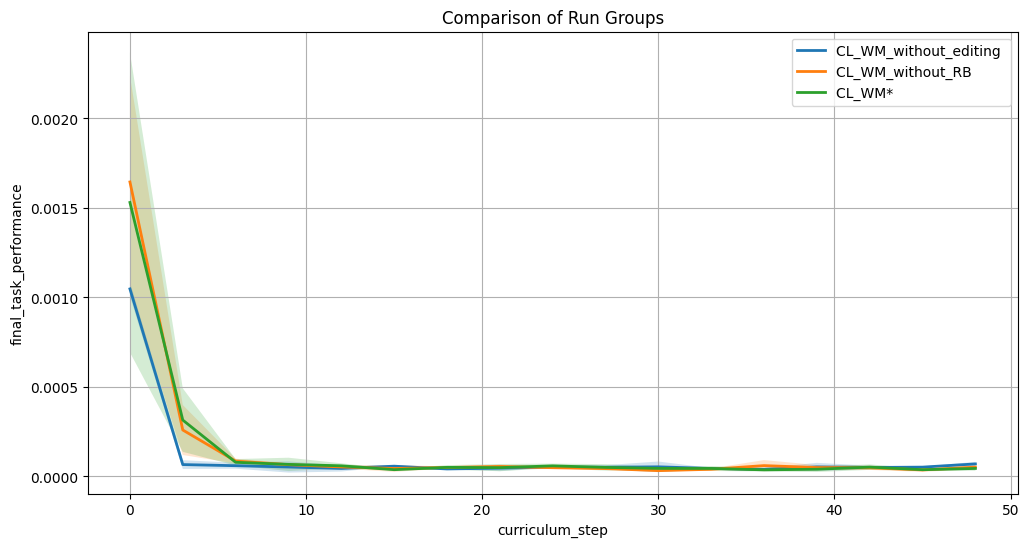

In [22]:
def load_group(prefix):
    runs = api.runs(f"{entity}/{project}")
    selected_runs = [run for run in runs if run.name.startswith(prefix)]
    print(f"\nGroup '{prefix}': Found {len(selected_runs)} runs")

    data_frames = []
    for run in selected_runs:
        try:
            history = run.history()
            if metric_name not in history.columns or step_key not in history.columns:
                print(f"Skipping {run.name}: missing '{metric_name}' or '{step_key}'")
                continue
            df = history[[step_key, metric_name]].dropna()
            df = df.groupby(step_key).mean().reset_index()
            df.rename(columns={metric_name: run.name}, inplace=True)
            data_frames.append(df.set_index(step_key))
            print(f"  Loaded {run.name}")
        except Exception as e:
            print(f"  Error loading {run.name}: {e}")

    if not data_frames:
        return None, None, None
    
    merged_df = pd.concat(data_frames, axis=1)
    mean = merged_df.mean(axis=1)
    std = merged_df.std(axis=1)

    return merged_df.index, mean, std

plt.figure(figsize=(12, 6))

for prefix in prefixes:
    steps, mean, std = load_group(prefix)
    if steps is None:
        continue
    
    # Filter to only include step range 0 to 50
    step_mask = (steps >= step_min) & (steps <= step_max)
    steps_filtered = steps[step_mask]
    mean_filtered = mean[step_mask]
    std_filtered = std[step_mask]
    
    plt.plot(steps_filtered, mean_filtered, linewidth=2, label=f"{prefix} ")
    plt.fill_between(steps_filtered, mean_filtered - std_filtered, mean_filtered + std_filtered, alpha=0.2)

plt.xlabel(step_key)
plt.ylabel(metric_name)
plt.title(f"Comparison of Run Groups")
plt.legend()
plt.grid(True)
plt.show()

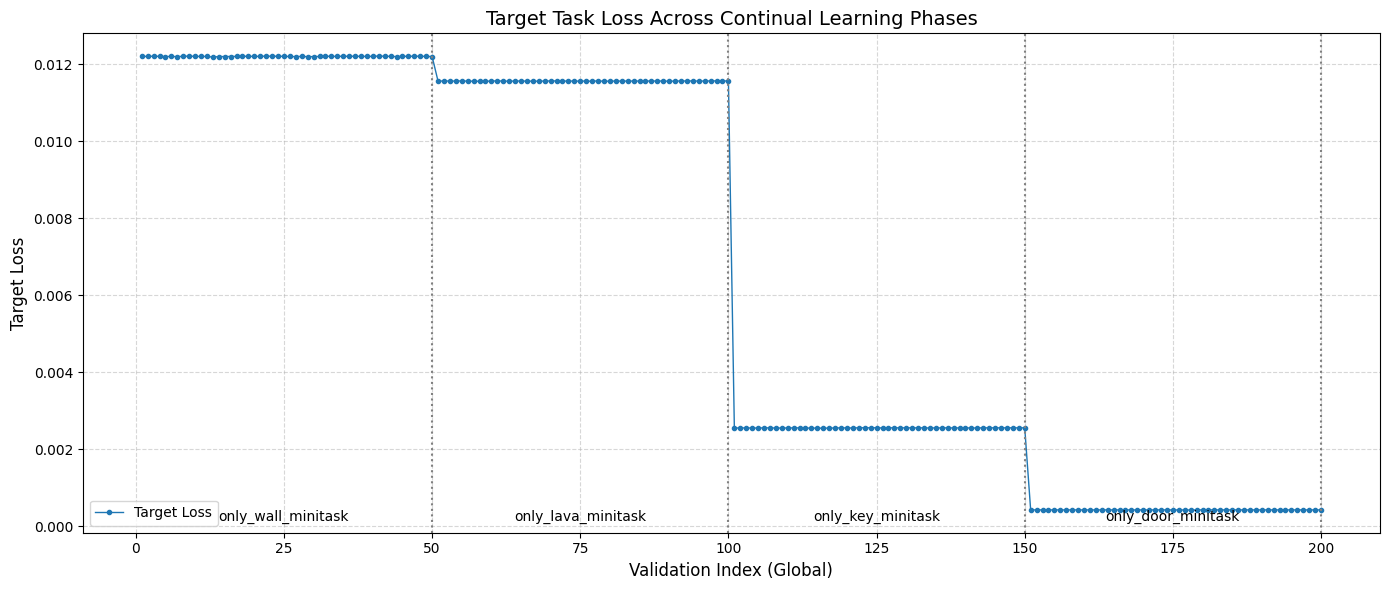

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load CSV
csv_path = "logs/target_eval_log.csv"  # Adjust if necessary
df = pd.read_csv(csv_path)

# Create a continuous index for x-axis
df['global_index'] = range(1, len(df) + 1)

# Create plot
plt.figure(figsize=(14, 6))
plt.plot(df['global_index'], df['target_loss'], marker='o', markersize=3, linewidth=1, label='Target Loss')

# Identify phase boundaries and centers
unique_phases = df['phase'].unique()
phase_centers = []

for phase in unique_phases:
    phase_data = df[df['phase'] == phase]
    start_idx = phase_data['global_index'].min()
    end_idx = phase_data['global_index'].max()
    phase_centers.append((start_idx + end_idx) // 2)
    # Draw boundary line at end of each phase
    plt.axvline(x=end_idx, linestyle='dotted', color='gray')

# Place labels at the bottom
min_loss = df['target_loss'].min()
y_text = min_loss * 0.995  # slightly below the minimum loss on the plot

for center, phase in zip(phase_centers, unique_phases):
    plt.text(center, y_text, phase, rotation=0, ha='center', va='top', fontsize=10)

# Styling
plt.title('Target Task Loss Across Continual Learning Phases', fontsize=14)
plt.xlabel('Validation Index (Global)', fontsize=12)
plt.ylabel('Target Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


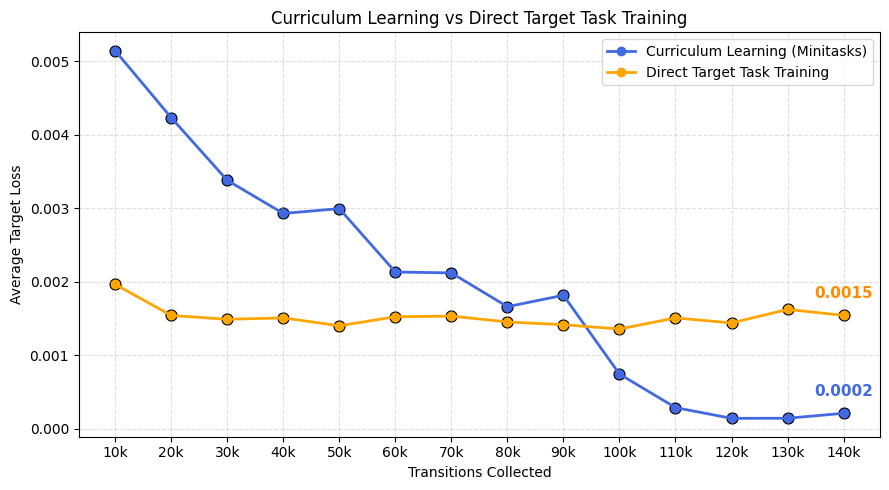

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_uniform.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


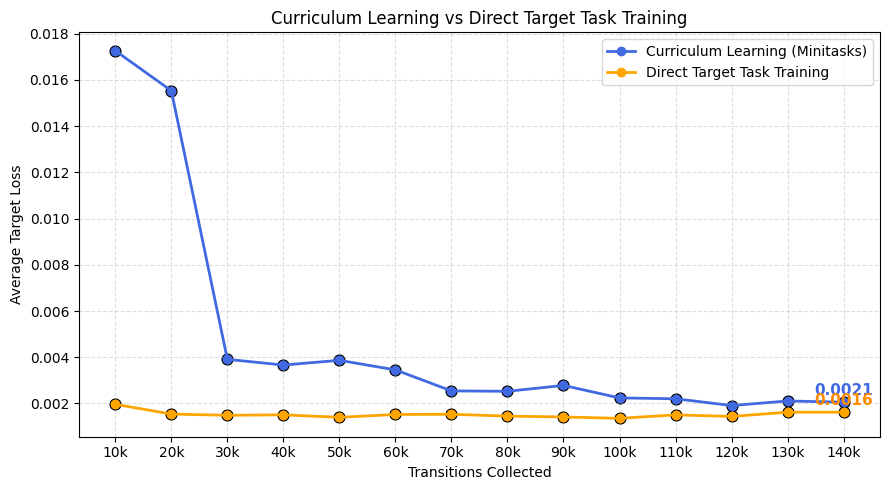

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_random.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()



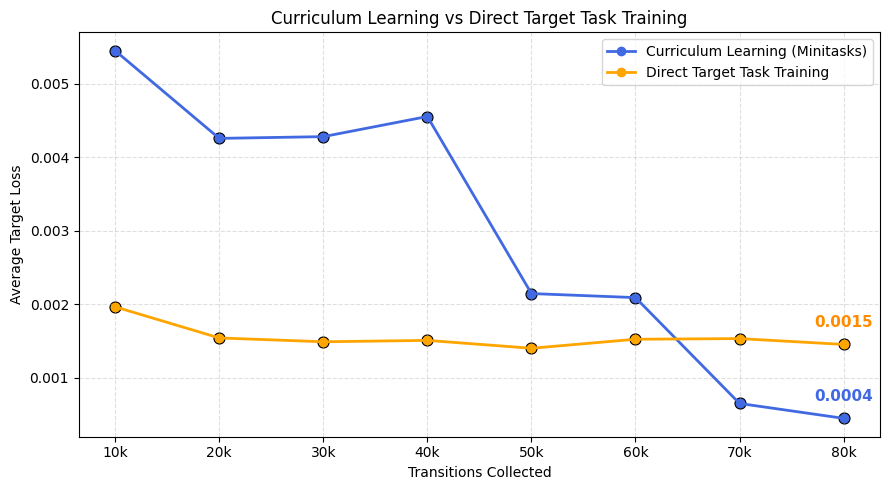

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_one_element.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


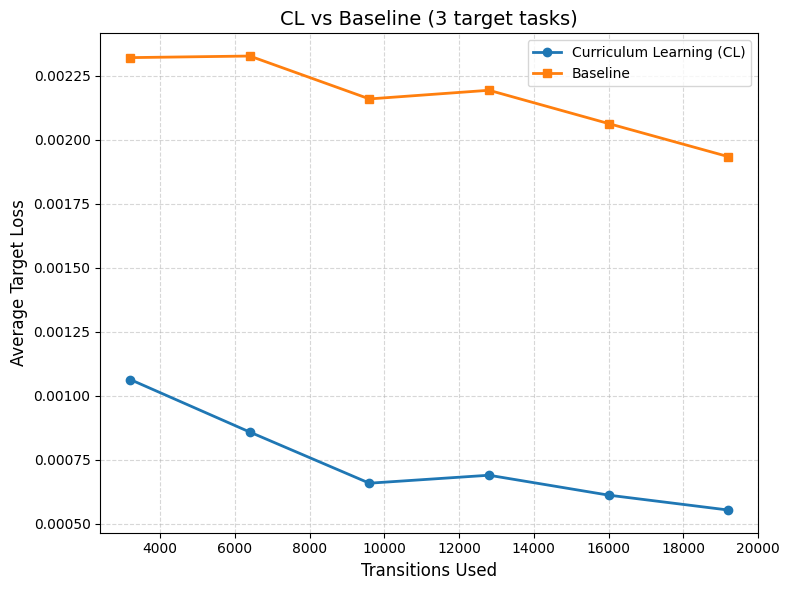

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_patches_minitask.csv"
df = pd.read_csv(csv_path)

# 2. 分离 CL 和 Baseline
df_cl = df[df['mode'] == 'CL']
df_baseline = df[df['mode'] == 'Baseline']

# 3. 按 transitions 排序（保证 x 轴递增）
df_cl = df_cl.sort_values(by='transitions')
df_baseline = df_baseline.sort_values(by='transitions')

# 4. 画图
plt.figure(figsize=(8,6))

plt.plot(df_cl['transitions'], df_cl['avg_target_loss'],
         marker='o', label='Curriculum Learning (CL)', linewidth=2)

plt.plot(df_baseline['transitions'], df_baseline['avg_target_loss'],
         marker='s', label='Baseline', linewidth=2)

# 5. 图表格式美化
plt.xlabel("Transitions Used", fontsize=12)
plt.ylabel("Average Target Loss", fontsize=12)
plt.title("CL vs Baseline (3 target tasks)", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.legend(loc="upper right")

plt.show()



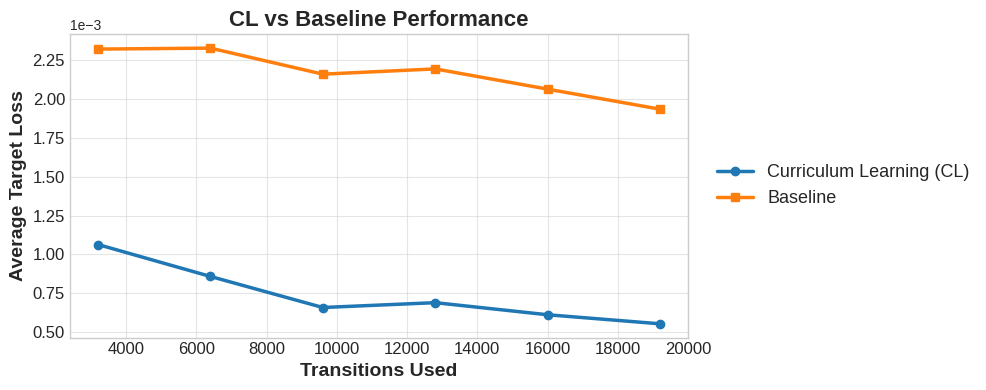

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ============= 1. 读取 CSV 文件 =============
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_3_targets.csv"  # 你的路径
df = pd.read_csv(csv_path)

# ============= 2. 拆分 CL 和 Baseline =============
df_cl = df[df["mode"] == "CL"].sort_values("transitions")
df_baseline = df[df["mode"] == "Baseline"].sort_values("transitions")

# ============= 3. 设置专业风格 =============
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 4))

# 更专业的颜色
color_cl = "#1f77b4"       # 专业深蓝
color_base = "#ff7f0e"     # 专业橙色

# ============= 4. 绘图 =============
ax.plot(
    df_cl["transitions"], df_cl["avg_target_loss"],
    marker="o", linewidth=2.5, markersize=6,
    label="Curriculum Learning (CL)",
    color=color_cl
)

ax.plot(
    df_baseline["transitions"], df_baseline["avg_target_loss"],
    marker="s", linewidth=2.5, markersize=6,
    label="Baseline",
    color=color_base
)

# ============= 5. 坐标轴美化 =============
ax.set_xlabel("Transitions Used", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Target Loss", fontsize=14, fontweight="bold")

ax.set_title("CL vs Baseline Performance", fontsize=16, fontweight="bold")

# 更专业的科学计数法（如果需要）
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

ax.tick_params(labelsize=12)

# ============= 6. 图例放在右侧，不遮挡曲线 =============
ax.legend(fontsize=13, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ============= 7. 网格更淡，不喧宾夺主 =============
ax.grid(alpha=0.5)

# ============= 8. 紧凑布局 + 保存高清图 =============
plt.tight_layout()
plt.show()


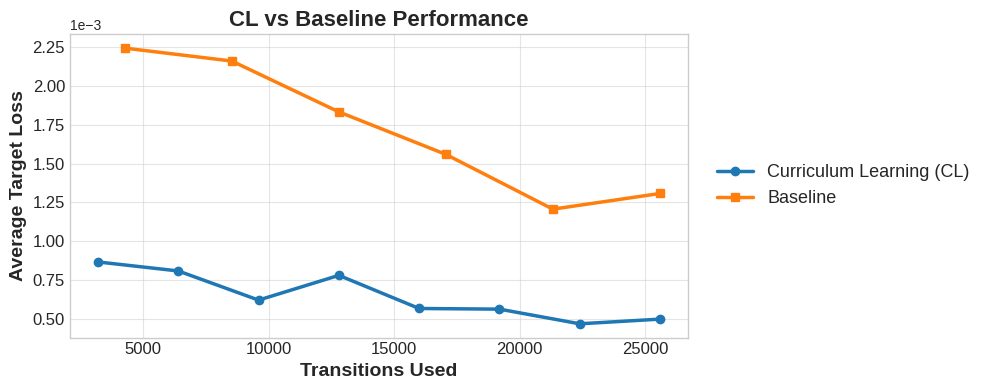

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ============= 1. 读取 CSV 文件 =============
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_6_targets.csv"  # 你的路径
df = pd.read_csv(csv_path)

# ============= 2. 拆分 CL 和 Baseline =============
df_cl = df[df["mode"] == "CL"].sort_values("transitions")
df_baseline = df[df["mode"] == "Baseline"].sort_values("transitions")

# ============= 3. 设置专业风格 =============
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 4))

# 更专业的颜色
color_cl = "#1f77b4"       # 专业深蓝
color_base = "#ff7f0e"     # 专业橙色

# ============= 4. 绘图 =============
ax.plot(
    df_cl["transitions"], df_cl["avg_target_loss"],
    marker="o", linewidth=2.5, markersize=6,
    label="Curriculum Learning (CL)",
    color=color_cl
)

ax.plot(
    df_baseline["transitions"], df_baseline["avg_target_loss"],
    marker="s", linewidth=2.5, markersize=6,
    label="Baseline",
    color=color_base
)

# ============= 5. 坐标轴美化 =============
ax.set_xlabel("Transitions Used", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Target Loss", fontsize=14, fontweight="bold")

ax.set_title("CL vs Baseline Performance", fontsize=16, fontweight="bold")

# 更专业的科学计数法（如果需要）
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

ax.tick_params(labelsize=12)

# ============= 6. 图例放在右侧，不遮挡曲线 =============
ax.legend(fontsize=13, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ============= 7. 网格更淡，不喧宾夺主 =============
ax.grid(alpha=0.5)

# ============= 8. 紧凑布局 + 保存高清图 =============
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
try:
    ued_df = pd.read_csv('logs/results/experiment_summary.csv')
    dr_df = pd.read_csv('logs/results_dr/experiment_summary_dr.csv')
except FileNotFoundError:
    # Fallback paths
    ued_df = pd.read_csv('trainer/logs/results/experiment_summary.csv')
    dr_df = pd.read_csv('trainer/logs/results_dr/experiment_summary_dr.csv')

# Plot 1: Generator Reward (UED only)
plt.figure(figsize=(10, 5))
plt.plot(ued_df['Iter'], ued_df['Gen_Mean_Reward'], label='UED Generator Reward', color='blue')
plt.title('UED Generator Mean Reward')
plt.xlabel('Iteration')
plt.ylabel('Reward')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: World Model Validation Loss Comparison
plt.figure(figsize=(10, 5))

# UED
plt.plot(ued_df['Iter'], ued_df['WM_Val_Loss'], label='UED WM Loss', color='blue')
plt.fill_between(ued_df['Iter'], 
                 ued_df['WM_Val_Loss'] - ued_df['WM_Val_Std'], 
                 ued_df['WM_Val_Loss'] + ued_df['WM_Val_Std'], 
                 color='blue', alpha=0.2)

# DR
plt.plot(dr_df['Iter'], dr_df['WM_Val_Loss'], label='DR WM Loss', color='orange')
plt.fill_between(dr_df['Iter'], 
                 dr_df['WM_Val_Loss'] - dr_df['WM_Val_Std'], 
                 dr_df['WM_Val_Loss'] + dr_df['WM_Val_Std'], 
                 color='orange', alpha=0.2)

plt.title('World Model Validation Loss: UED vs DR')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

Reading UED CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv
Reading Baseline CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/target_loss_baseline_ued_mse.csv
Filtering UED data (Iter > 30)...
Plot saved to: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png


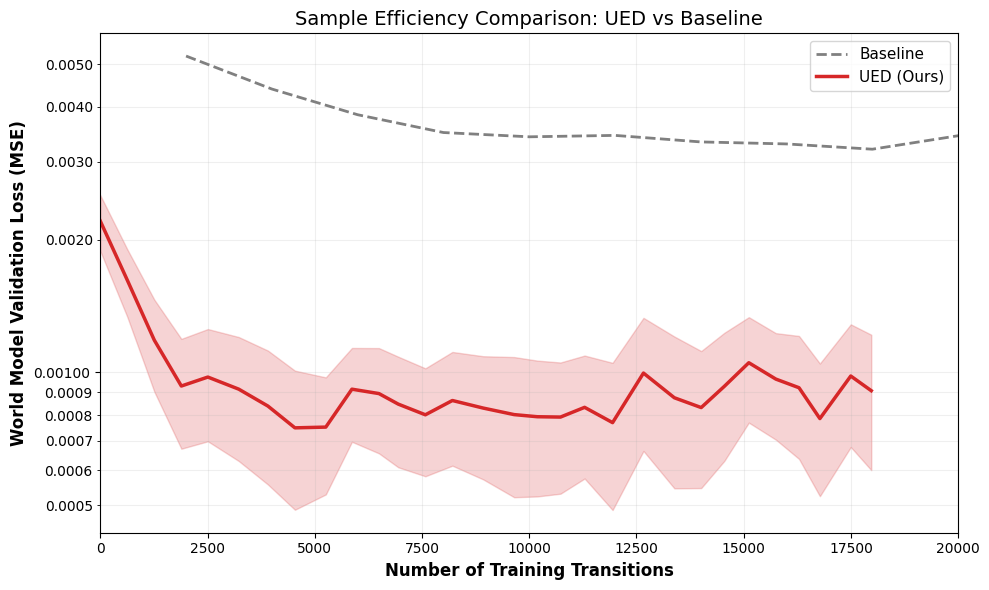

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv" 
# NOTE: User mentioned "target_loss_baseline_ued_mse.csv" but that sounds like a target task eval file?
# I will use the DR summary file I know usually exists. 
# WAIT - User EXPLICITLY said "target_loss_baseline_ued_mse.csv" is one of the data files.
# Let me check if that file exists first, otherwise I might fail.
# Actually, the user prompt says: "target_loss_baseline_ued_mse.csv experiment_summary_mask3_mse这两个是数据"
# So I MUST use those provided paths.

BASELINE_Target_CSV = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/target_loss_baseline_ued_mse.csv"
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_Target_CSV}")
    try:
        # Baseline CSV has no header: 0,Baseline,Combined_P1_to_P1,6000,0.0029
        df_base = pd.read_csv(BASELINE_Target_CSV, header=None)
        # Assign meaningful names based on inspection
        # Col 3 is Buffer Size (6000, 12000...), Col 4 is Loss
        df_base.columns = ['Iter', 'Label', 'Task', 'Buffer_Size', 'WM_Val_Loss']
        
    except FileNotFoundError:
        # Fallback to the DR summary path I know
        fallback = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv"
        print(f"Warning: User file not found. Trying fallback: {fallback}")
        if os.path.exists(fallback):
            df_base = pd.read_csv(fallback) # This one likely HAS headers if it's summary
        else:
            print("Error: Baseline file not found.")
            return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 31
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 30)...")
        df_ued = df_ued[df_ued['Iter'] > 30].copy()
        # Optional: Reset Buffer_Size to start closer to 0? 
        # Usually for comparison "Sample Efficiency", we keep the absolute X value.
        # But if Iter 1-30 was "Pre-training" that shouldn't count against UED, we might shift.
        # For now, let's keep X absolute (Total Samples Consumed).
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size (Total Transitions)
    # Check if column exists
    x_col = 'Buffer_Size'
    if x_col not in df_ued.columns:
        x_col = 'New_Data_Size' # Fallback
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # --- Plot Baseline (DR) ---
    # Baseline usually has less variance, just plot mean line
    if 'WM_Val_Loss' in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Baseline', color='gray', linestyle='--', linewidth=2)
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # [MODIFIED] Shift X-axis so Iter 31 starts at 0 (or close to it)
        # This aligns the "Effective Training Phase" with the Baseline
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Calculate upper/lower bounds for shading
        # Priority: Max/Min columns -> Std -> None
        if 'WM_Val_Max' in df_ued.columns and 'WM_Val_Std' in df_ued.columns:
            # Option A: Mean +/- Std
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
            
            # Alternative: Use Max as upper bound?
            # upper = df_ued['WM_Val_Max'] 
            # Let's stick to Std for scientific look
            
        else:
            lower = y_ued * 0.9 # Fake shading if no data
            upper = y_ued * 1.1

        # Smooth lines
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        # We need to smooth bounds too to match
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale is often better for Loss
    plt.yscale('log')
    from matplotlib.ticker import ScalarFormatter
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(0, 20000) # [MODIFIED] Limit X-axis to 20k as requested
    
    plt.tight_layout()
    
    # Save
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


Reading UED CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv
Reading Baseline CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv
Filtering UED data (Iter > 30)...
Plot saved to: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png


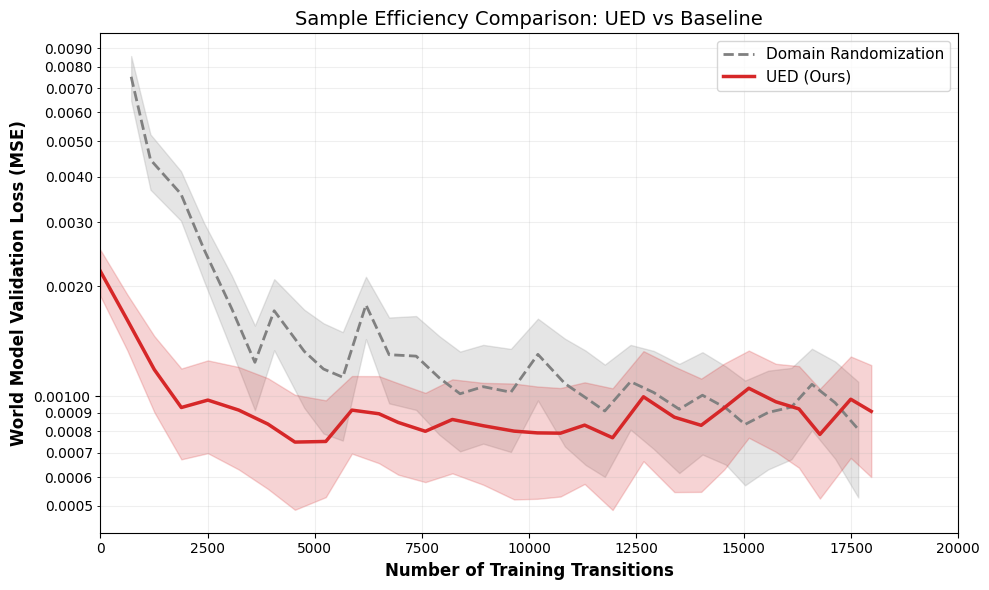

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 31
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 30)...")
        df_ued = df_ued[df_ued['Iter'] > 30].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    
    # --- Plot Baseline (DR) ---
    if y_col in df_base.columns and x_col in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        
        # Add Std Shading for Baseline
        if 'WM_Val_Std' in df_base.columns:
            std_base = df_base['WM_Val_Std']
            lower_base = y_base - std_base
            upper_base = y_base + std_base
            
            lower_base_smooth = smooth(lower_base.values, 0.5)
            upper_base_smooth = smooth(upper_base.values, 0.5)
            
            plt.fill_between(x_base, lower_base_smooth, upper_base_smooth, color='gray', alpha=0.2)
    else:
        print(f"Warning: Columns {x_col} or {y_col} not found in Baseline CSV.")
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns and x_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # Shift X-axis so Iter 31 starts at 0
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Shading
        if 'WM_Val_Std' in df_ued.columns:
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
        else:
            lower = y_ued * 0.9 
            upper = y_ued * 1.1

        # Smooth
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale & Ticks
    plt.yscale('log')
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Limit X
    plt.xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


Reading UED CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv
Reading Baseline CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv
Filtering UED data (Iter > 20)...
Plot saved to: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png


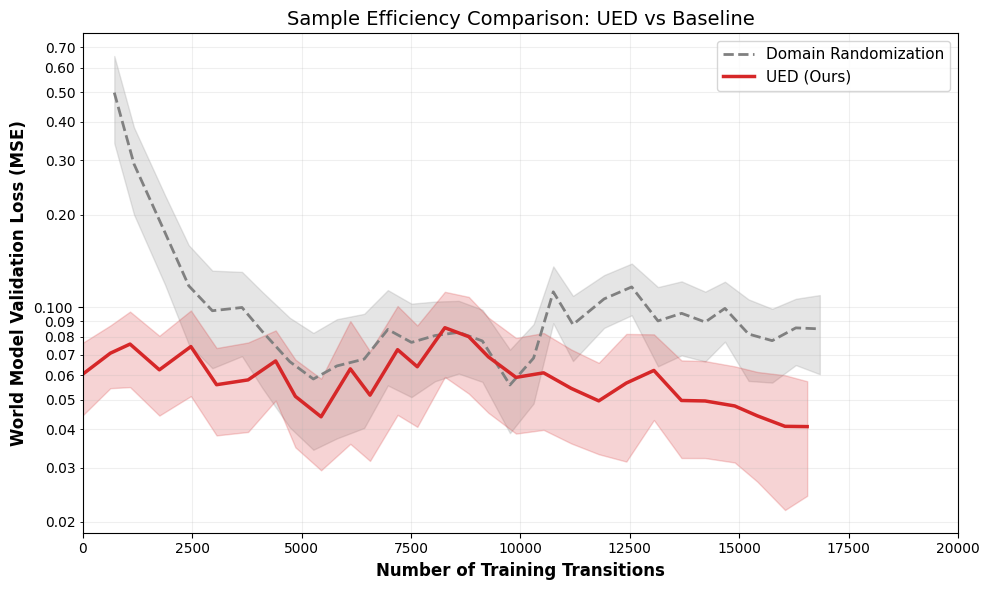

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 21
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 20)...")
        df_ued = df_ued[df_ued['Iter'] > 20].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    
    # --- Plot Baseline (DR) ---
    if y_col in df_base.columns and x_col in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        
        # Add Std Shading for Baseline
        if 'WM_Val_Std' in df_base.columns:
            std_base = df_base['WM_Val_Std']
            lower_base = y_base - std_base
            upper_base = y_base + std_base
            
            lower_base_smooth = smooth(lower_base.values, 0.5)
            upper_base_smooth = smooth(upper_base.values, 0.5)
            
            plt.fill_between(x_base, lower_base_smooth, upper_base_smooth, color='gray', alpha=0.2)
    else:
        print(f"Warning: Columns {x_col} or {y_col} not found in Baseline CSV.")
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns and x_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # Shift X-axis so Iter 31 starts at 0
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Shading
        if 'WM_Val_Std' in df_ued.columns:
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
        else:
            lower = y_ued * 0.9 
            upper = y_ued * 1.1

        # Smooth
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale & Ticks
    plt.yscale('log')
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Limit X
    plt.xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


Reading UED CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv
Reading Baseline CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv
Filtering UED data (Iter > 20)...
Plot saved to: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png


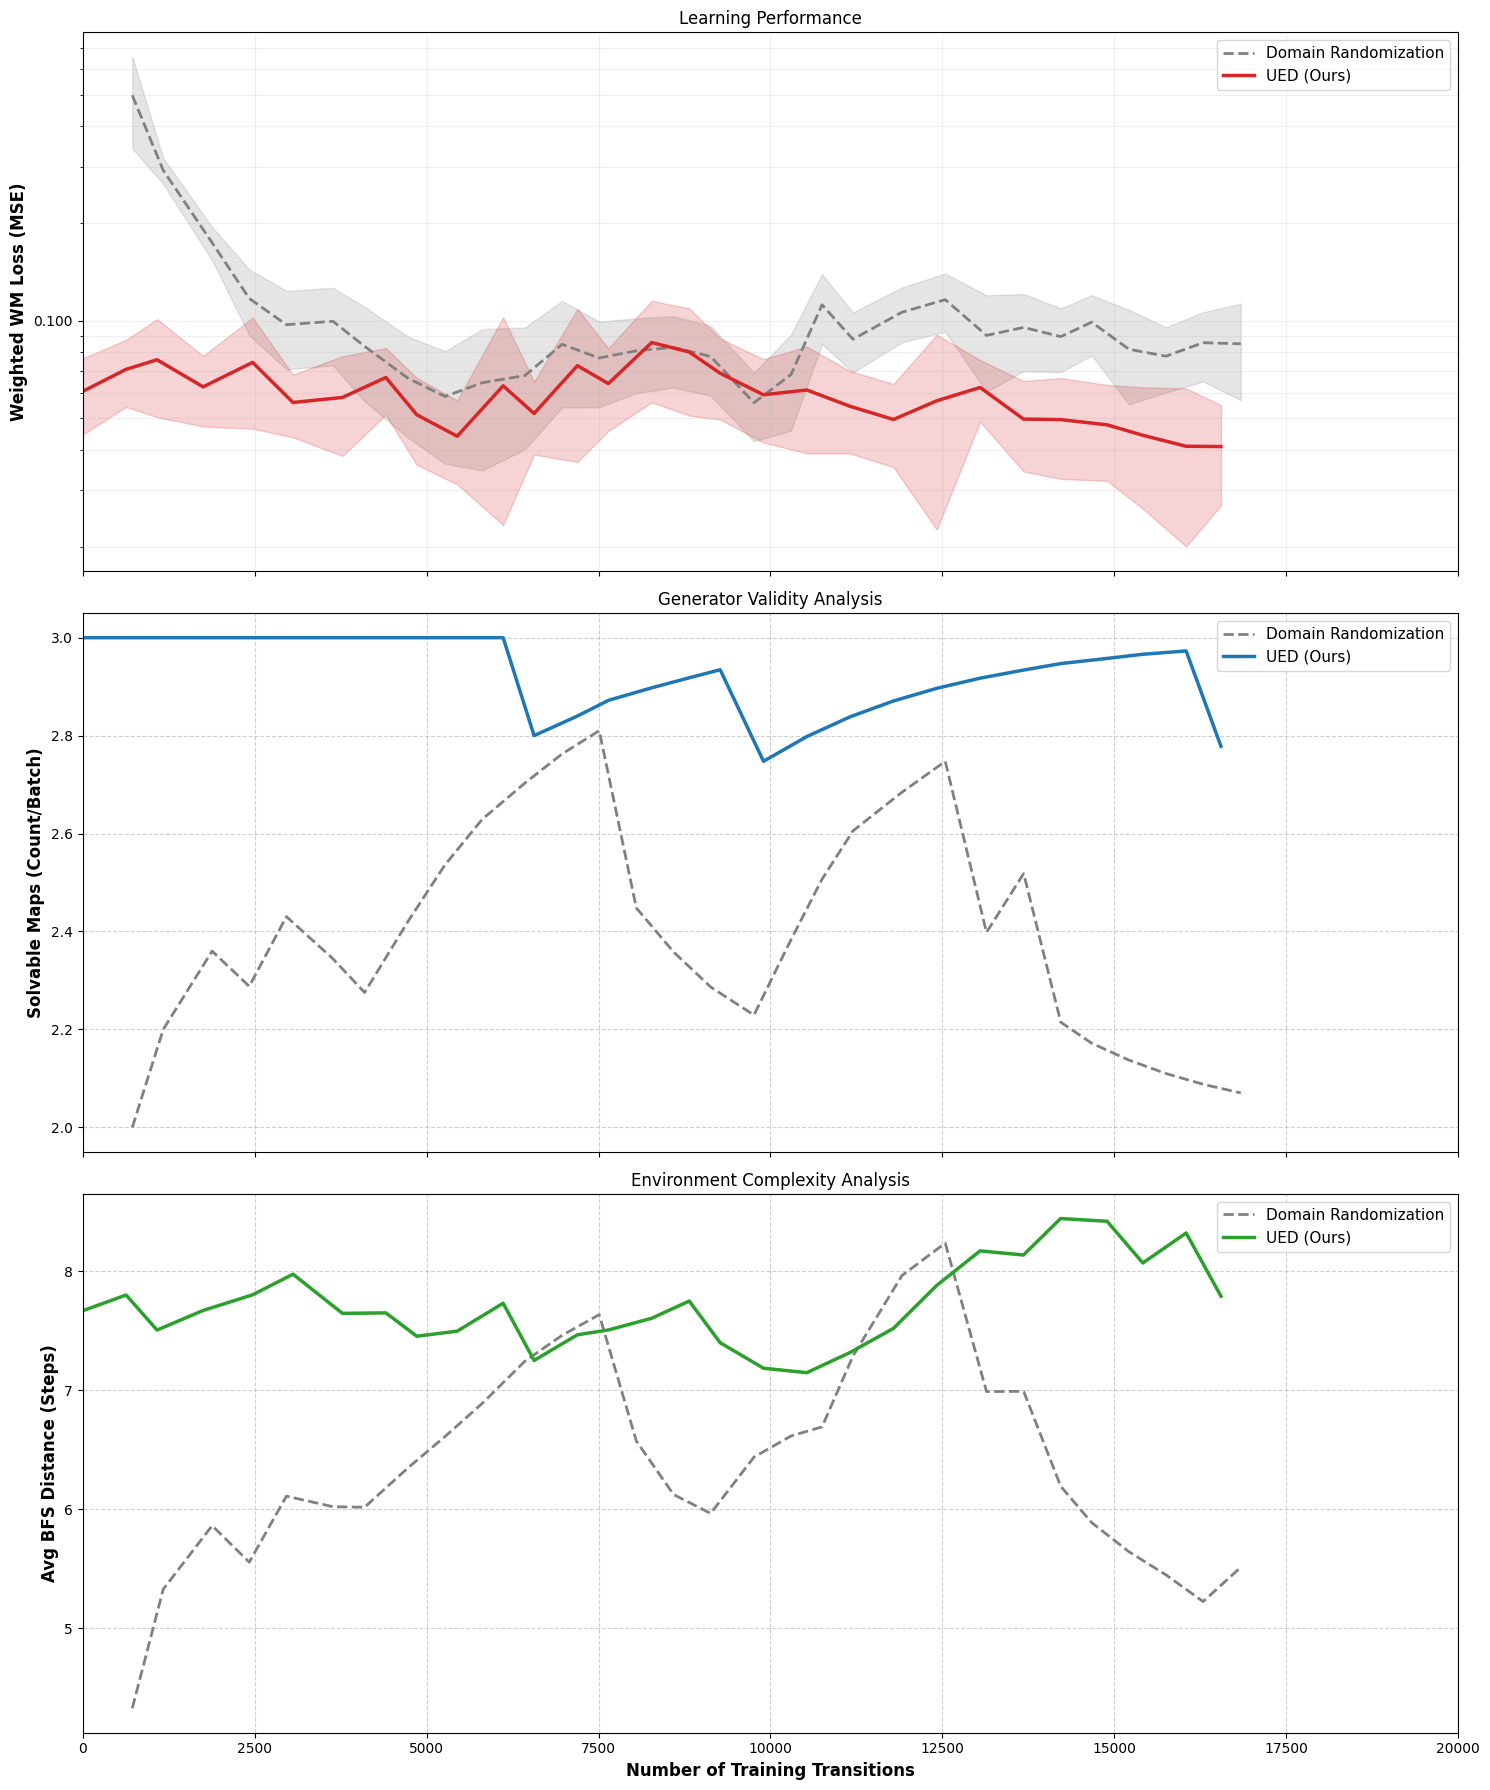

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 21
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 20)...")
        df_ued = df_ued[df_ued['Iter'] > 20].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    fig, axes = plt.subplots(3, 1, figsize=(18, 18), sharex=True)
    
    # ---------------------------------------------------------
    # Subplot 1: Validation Loss (Log Scale)
    # ---------------------------------------------------------
    ax = axes[0]
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    if y_col in df_base.columns:
        y_base_smooth = smooth(df_base[y_col].values, 0.5)
        ax.plot(df_base[x_col], y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        if 'WM_Val_Std' in df_base.columns:
             std = df_base['WM_Val_Std']
             ax.fill_between(df_base[x_col], y_base_smooth - std, y_base_smooth + std, color='gray', alpha=0.2)
             
    if y_col in df_ued.columns:
        y_ued_smooth = smooth(df_ued[y_col].values, 0.5)
        x_ued = df_ued[x_col]
        if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
        
        ax.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5)
        
        # Shade
        if 'WM_Val_Std' in df_ued.columns:
             std = df_ued['WM_Val_Std']
             ax.fill_between(x_ued, y_ued_smooth - std, y_ued_smooth + std, color='#d62728', alpha=0.2)

    ax.set_ylabel('Weighted WM Loss (MSE)', fontsize=12, fontweight='bold')
    ax.set_title('Learning Performance', fontsize=12)
    ax.legend(fontsize=11)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ScalarFormatter())
    
    # ---------------------------------------------------------
    # Subplot 2: Solvable Count (Valid Maps per Batch)
    # ---------------------------------------------------------
    ax = axes[1]
    ax.grid(True, linestyle='--', alpha=0.6)
    metric = 'Solvable_Count'
    
    if metric in df_base.columns:
         y_smooth = smooth(df_base[metric].values, 0.8) # Smoother
         ax.plot(df_base[x_col], y_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
         
    if metric in df_ued.columns:
         y_smooth = smooth(df_ued[metric].values, 0.8)
         x_ued = df_ued[x_col]
         if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
         ax.plot(x_ued, y_smooth, label='UED (Ours)', color='#1f77b4', linewidth=2.5) # Blue for Solvability
    
    ax.set_ylabel('Solvable Maps (Count/Batch)', fontsize=12, fontweight='bold')
    ax.set_title('Generator Validity Analysis', fontsize=12)
    ax.legend(fontsize=11)
    
    # ---------------------------------------------------------
    # Subplot 3: Avg BFS Path Length (Complexity)
    # ---------------------------------------------------------
    ax = axes[2]
    ax.grid(True, linestyle='--', alpha=0.6)
    metric = 'Avg_Path_Len'
    
    if metric in df_base.columns:
         y_smooth = smooth(df_base[metric].values, 0.8)
         ax.plot(df_base[x_col], y_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)

    if metric in df_ued.columns:
         y_smooth = smooth(df_ued[metric].values, 0.8)
         x_ued = df_ued[x_col]
         if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
         ax.plot(x_ued, y_smooth, label='UED (Ours)', color='#2ca02c', linewidth=2.5) # Green for Complexity

    ax.set_ylabel('Avg BFS Distance (Steps)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    ax.set_title('Environment Complexity Analysis', fontsize=12)
    ax.legend(fontsize=11)

    # Common Logic
    for ax in axes:
        ax.set_xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()
